# Quantile Mapping (QM) aplicado a precipitación
## Respuestas metodológicas y ejemplo reproducible con MPI-ESM1-2-HR y la estación Carolina (27010500)

Este notebook responde, con base en literatura científica y en los datos suministrados, las siguientes preguntas:

1. **¿Qué es Quantile Mapping?**
2. **¿Cómo se construyen las funciones de distribución de probabilidades acumuladas (CDF/ECDF) para las series observada y simulada?**
3. **¿Cómo se aplica la técnica en hidrometeorología?**
4. **¿Cómo se puede ilustrar un ejemplo de downscaling/postprocesamiento de precipitación?**

Se emplean los archivos suministrados `data QM.csv` o `data Quantil Mapping.ods`, que contienen la misma información en formatos diferentes.

> **Nota terminológica importante.** En sentido estricto, QM es una técnica de **ajuste de sesgo de la distribución marginal**. Puede utilizarse como transformación hacia una escala de estación cuando se relaciona una simulación de modelo con observaciones puntuales, como en Gudmundsson et al. (2012). Sin embargo, cuando existe una fuerte diferencia de escala entre una celda GCM/RCM y una estación, QM no genera por sí mismo la variabilidad espacial subgrid y puede inducir problemas de “inflación” (Maraun, 2013). Por ello, en este notebook el término *downscaling* se usa en el sentido de **postprocesamiento estadístico univariado hacia la distribución de una estación**, explicitando esta limitación.

### Fuentes metodológicas principales

- [Gudmundsson et al. (2012), *Hydrology and Earth System Sciences*](https://doi.org/10.5194/hess-16-3383-2012)
- [Piani et al. (2010), *Theoretical and Applied Climatology*](https://doi.org/10.1007/s00704-009-0134-9)
- [Themeßl et al. (2011), *International Journal of Climatology*](https://doi.org/10.1002/joc.2168)
- [Maraun (2013), *Journal of Climate*](https://doi.org/10.1175/JCLI-D-12-00821.1)
- [Cannon et al. (2015), *Journal of Climate*](https://doi.org/10.1175/JCLI-D-14-00754.1)
- [Eyring et al. (2016), diseño de CMIP6](https://doi.org/10.5194/gmd-9-1937-2016)

## 0. Preparación del entorno y lectura de datos

El código busca primero el archivo CSV, porque es el formato más directo para Colab. Si el archivo no está disponible, permite cargar manualmente el `.csv` o el `.ods`.

El CSV suministrado tiene dos bloques de columnas:

- **Modelo climático:** fecha, precipitación diaria y nombre del modelo.
- **Observación:** fecha, precipitación diaria y nombre/código de la estación.

Las cifras utilizan coma decimal, por lo que se transforman explícitamente a `float`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

candidatos = [
    Path("/content/data QM.csv"),
    Path("data QM.csv"),
    Path("/mnt/data/data QM.csv"),
    Path("/content/data Quantil Mapping.ods"),
    Path("data Quantil Mapping.ods"),
    Path("/mnt/data/data Quantil Mapping.ods"),
]

data_path = next((p for p in candidatos if p.exists()), None)

if data_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        data_path = Path(next(iter(uploaded.keys())))
    except Exception as e:
        raise FileNotFoundError(
            "No se encontró el archivo. En Colab, suba 'data QM.csv' "
            "o 'data Quantil Mapping.ods'."
        ) from e

print("Archivo utilizado:", data_path)

def a_numero_serie(s):
    return pd.to_numeric(
        s.astype(str).str.strip().str.replace(",", ".", regex=False),
        errors="coerce"
    )

if data_path.suffix.lower() == ".csv":
    raw = pd.read_csv(data_path, header=2, dtype=str)
elif data_path.suffix.lower() == ".ods":
    try:
        raw = pd.read_excel(data_path, header=2, dtype=str, engine="odf")
    except ImportError as e:
        raise ImportError(
            "Para leer .ods instale odfpy en Colab con: !pip -q install odfpy"
        ) from e
else:
    raise ValueError("Formato no soportado. Use CSV u ODS.")

modelo = pd.DataFrame({
    "fecha": pd.to_datetime(raw.iloc[:, 0], dayfirst=True, errors="coerce"),
    "pr_mm_dia": a_numero_serie(raw.iloc[:, 1]),
    "modelo": raw.iloc[:, 2].astype(str).str.strip()
}).dropna(subset=["fecha", "pr_mm_dia"])

observado = pd.DataFrame({
    "fecha": pd.to_datetime(raw.iloc[:, 4], dayfirst=True, errors="coerce"),
    "pr_mm_dia": a_numero_serie(raw.iloc[:, 5]),
    "estacion": raw.iloc[:, 6].astype(str).str.strip()
}).dropna(subset=["fecha", "pr_mm_dia"])

modelo = modelo.sort_values("fecha").reset_index(drop=True)
observado = observado.sort_values("fecha").reset_index(drop=True)

print("Modelo:", modelo["modelo"].dropna().unique()[:5])
print("Estación:", observado["estacion"].dropna().unique()[:5])
print("Registros modelo:", len(modelo))
print("Registros observados:", len(observado))

Archivo utilizado: data QM.csv


Modelo: ['MPI-ESM1-2-HR']
Estación: ['Carolina (27010500)']
Registros modelo: 55152
Registros observados: 24462


In [2]:
def inventario(df, etiqueta, nombre_col):
    return pd.DataFrame({
        "Serie": [etiqueta],
        "Identificador": [", ".join(df[nombre_col].dropna().astype(str).unique())],
        "Fecha inicial": [df["fecha"].min().date()],
        "Fecha final": [df["fecha"].max().date()],
        "N": [len(df)],
        "NaN precipitación": [int(df["pr_mm_dia"].isna().sum())],
        "Mínimo (mm/d)": [df["pr_mm_dia"].min()],
        "Máximo (mm/d)": [df["pr_mm_dia"].max()],
    })

inventario_datos = pd.concat([
    inventario(modelo, "Modelo climático", "modelo"),
    inventario(observado, "Observado", "estacion")
], ignore_index=True)

display(inventario_datos)

,Serie,Identificador,Fecha inicial,Fecha final,N,NaN precipitación,Mínimo (mm/d),Máximo (mm/d)
0,Modelo climático,MPI-ESM1-2-HR,1950-01-01,2100-12-31,55152,0,1.120000e-13,41.094185
1,Observado,Carolina (27010500),1959-01-01,2025-12-21,24462,0,0.000000e+00,153.100000


### Periodo de referencia utilizado

El archivo identifica el modelo **MPI-ESM1-2-HR** y contiene valores desde 1950 hasta 2100. La estación observada comienza en 1959.

Para el ejemplo se adopta **1959-01-01 a 2014-12-31** como periodo de referencia. La elección de 2014 es consistente con el límite del experimento histórico de CMIP6; a partir de 2015 comienzan los experimentos de escenarios. El archivo entregado, sin embargo, **no contiene una columna que identifique el escenario** posterior a 2014. Por tanto, la aplicación 2015–2100 que se muestra más adelante es **demostrativa** y no debe interpretarse físicamente hasta verificar el escenario y la realización del modelo.

Referencia: Eyring et al. (2016), [https://doi.org/10.5194/gmd-9-1937-2016](https://doi.org/10.5194/gmd-9-1937-2016)

In [3]:
CAL_START = pd.Timestamp("1959-01-01")
CAL_END   = pd.Timestamp("2014-12-31")
WET_THRESHOLD = 0.1  # mm/d

mod_cal = modelo.loc[
    modelo["fecha"].between(CAL_START, CAL_END),
    ["fecha", "pr_mm_dia"]
].rename(columns={"pr_mm_dia": "modelo_mm"})

obs_cal = observado.loc[
    observado["fecha"].between(CAL_START, CAL_END),
    ["fecha", "pr_mm_dia"]
].rename(columns={"pr_mm_dia": "obs_mm"})

cal = mod_cal.merge(obs_cal, on="fecha", how="inner").dropna()
cal["mes"] = cal["fecha"].dt.month

print("Periodo de referencia:", cal["fecha"].min().date(), "a", cal["fecha"].max().date())
print("Días comunes:", len(cal))
print("Fechas duplicadas:", int(cal["fecha"].duplicated().sum()))

esperados = pd.date_range(CAL_START, CAL_END, freq="D")
faltantes = esperados.difference(cal["fecha"])
print("Días esperados:", len(esperados))
print("Días faltantes en el periodo común:", len(faltantes))

Periodo de referencia: 1959-01-01 a 2014-12-31
Días comunes: 20454
Fechas duplicadas: 0
Días esperados: 20454
Días faltantes en el periodo común: 0


# 1) ¿Qué es Quantile Mapping?

**Quantile Mapping (QM)** es una transformación estadística que corrige sesgos distribucionales de una serie simulada utilizando una serie observada de referencia. La idea no es corregir únicamente la media: se busca que los cuantiles de la distribución simulada correspondan a los cuantiles de la distribución observada.

Sea:

- \(X_m\): variable simulada por el modelo;
- \(F_m\): función de distribución acumulada (CDF) de la simulación durante el periodo de referencia;
- \(F_o\): CDF de las observaciones;
- \(F_o^{-1}\): función cuantil o CDF inversa observada.

El QM clásico se expresa como:

\[
\boxed{
X_{\mathrm{QM}} = F_o^{-1}\left[F_m(X_m)\right]
}
\]

El procedimiento puede leerse en cuatro pasos:

\[
X_m
\;\longrightarrow\;
p=F_m(X_m)
\;\longrightarrow\;
F_o^{-1}(p)
\;\longrightarrow\;
X_{\mathrm{QM}}
\]

Es decir, primero se determina **qué posición cuantílica ocupa un valor simulado** dentro de la distribución del modelo y después se busca **qué valor observado ocupa esa misma posición cuantílica**.

Gudmundsson et al. (2012) describen este tipo de transformaciones para postprocesar precipitación de modelos regionales, y Themeßl et al. (2011) reportan buen desempeño de QM en la reducción de sesgos de precipitación, incluidos cuantiles altos.

**Referencias:**  
Gudmundsson et al. (2012): [https://doi.org/10.5194/hess-16-3383-2012](https://doi.org/10.5194/hess-16-3383-2012)  
Themeßl et al. (2011): [https://doi.org/10.1002/joc.2168](https://doi.org/10.1002/joc.2168)

## 1.1 Ejemplo pedagógico con los valores propuestos

El siguiente bloque conserva el ejemplo sencillo suministrado. Sirve para visualizar la mecánica del método antes de trabajar con las series reales.

In [4]:
modelo_ej = np.array([2, 5, 8, 12, 15, 20, 25, 30, 40, 50], dtype=float)
observado_ej = np.array([1, 4, 7, 10, 14, 18, 28, 35, 48, 65], dtype=float)

modelo_ord = np.sort(modelo_ej)
obs_ord = np.sort(observado_ej)

percentiles = np.searchsorted(modelo_ord, modelo_ej, side="right") / len(modelo_ord)
qm_ej = np.quantile(obs_ord, percentiles)

tabla_ej = pd.DataFrame({
    "Modelo (mm)": modelo_ej,
    "Cuantil p": percentiles,
    "QM (mm)": np.round(qm_ej, 2),
    "Observado (mm)": observado_ej
})

display(tabla_ej)

,Modelo (mm),Cuantil p,QM (mm),Observado (mm)
0,2.0,0.1,3.7,1.0
1,5.0,0.2,6.4,4.0
2,8.0,0.3,9.1,7.0
3,12.0,0.4,12.4,10.0
4,15.0,0.5,16.0,14.0
5,20.0,0.6,22.0,18.0
6,25.0,0.7,30.1,28.0
7,30.0,0.8,37.6,35.0
8,40.0,0.9,49.7,48.0
9,50.0,1.0,65.0,65.0


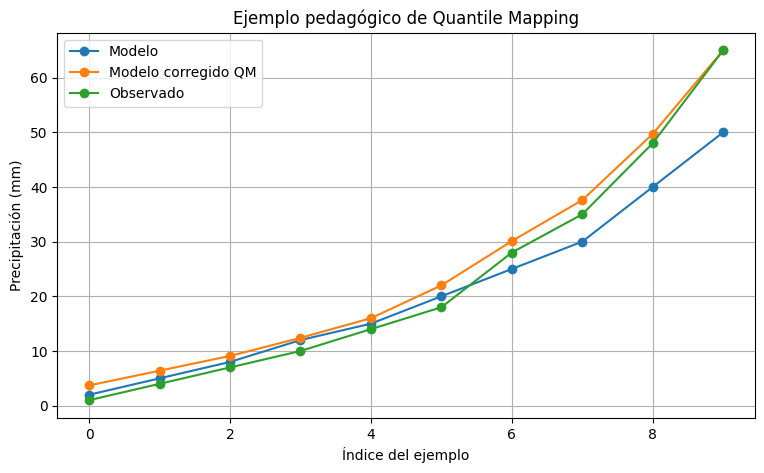

In [5]:
plt.figure()
plt.plot(modelo_ej, marker="o", label="Modelo")
plt.plot(qm_ej, marker="o", label="Modelo corregido QM")
plt.plot(observado_ej, marker="o", label="Observado")
plt.xlabel("Índice del ejemplo")
plt.ylabel("Precipitación (mm)")
plt.title("Ejemplo pedagógico de Quantile Mapping")
plt.legend()
plt.show()

# 2) ¿Cómo se construyen las funciones de distribución acumulada observada y simulada?

Para una muestra \(x_1,\ldots,x_n\), la **función de distribución empírica acumulada** (ECDF) se define como:

\[
\boxed{
\widehat{F}_n(x)=\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}(x_i\le x)
}
\]

donde \(\mathbf{1}(\cdot)\) vale 1 cuando la condición se cumple y 0 en caso contrario.

En términos operativos:

1. Se selecciona un **periodo común de referencia** entre modelo y observación.
2. Se ordenan de menor a mayor los valores de cada serie.
3. Se asigna a cada valor su probabilidad acumulada o rango empírico.
4. Se obtiene una ECDF para el modelo, \(\widehat F_m\), y otra para las observaciones, \(\widehat F_o\).
5. El QM utiliza \(\widehat F_m(x)\) para localizar el cuantil y la función cuantil observada \(\widehat F_o^{-1}(p)\) para obtener el valor corregido.

Cuando las longitudes de las series son diferentes no es necesario emparejar valor por valor: las distribuciones pueden estimarse por separado y compararse mediante una malla común de probabilidades. Gudmundsson et al. (2012) comparan varias transformaciones paramétricas y no paramétricas y encuentran alta capacidad de las transformaciones no paramétricas para reducir sesgos de precipitación.

### Particularidad de la precipitación

La precipitación diaria contiene una **masa de probabilidad en cero** y una distribución continua, positiva y asimétrica para los días húmedos. Por eso el tratamiento de la frecuencia seco/húmedo es fundamental. Los modelos climáticos suelen presentar exceso de llovizna (*drizzle effect*), es decir, demasiados días con precipitación pequeña (Piani et al., 2010).

En este notebook se adopta \(P < 0.1\,\mathrm{mm\,d^{-1}}\) como día seco para la demostración. El umbral debe justificarse para cada base de datos y aplicación.

Piani et al. (2010): [https://doi.org/10.1007/s00704-009-0134-9](https://doi.org/10.1007/s00704-009-0134-9)

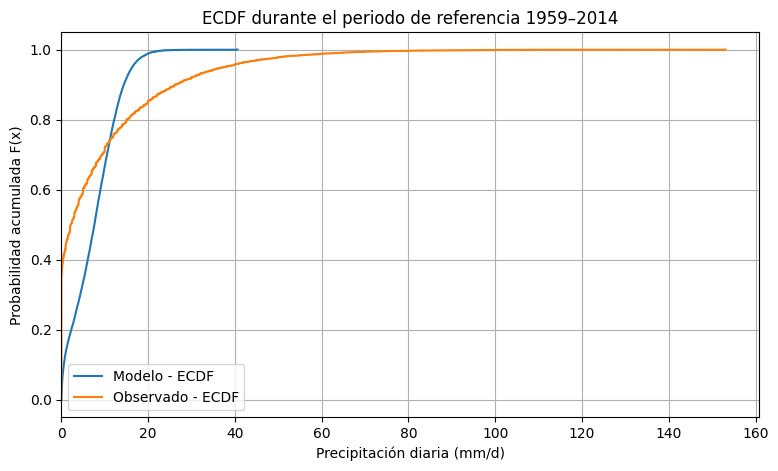

In [6]:
def ecdf(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    p = np.arange(1, len(x) + 1) / len(x)
    return x, p

x_mod, p_mod = ecdf(cal["modelo_mm"])
x_obs, p_obs = ecdf(cal["obs_mm"])

plt.figure()
plt.step(x_mod, p_mod, where="post", label="Modelo - ECDF")
plt.step(x_obs, p_obs, where="post", label="Observado - ECDF")
plt.xlabel("Precipitación diaria (mm/d)")
plt.ylabel("Probabilidad acumulada F(x)")
plt.title("ECDF durante el periodo de referencia 1959–2014")
plt.xlim(left=0)
plt.legend()
plt.show()

In [7]:
def metricas_precipitacion(x, wet_threshold=WET_THRESHOLD):
    x = np.asarray(x, dtype=float)
    return {
        "N": len(x),
        "Media (mm/d)": np.mean(x),
        "Mediana (mm/d)": np.median(x),
        "P95 (mm/d)": np.quantile(x, 0.95),
        "P99 (mm/d)": np.quantile(x, 0.99),
        "Máximo (mm/d)": np.max(x),
        "Frecuencia húmeda (%)": 100*np.mean(x >= wet_threshold),
        "Frecuencia seca (%)": 100*np.mean(x < wet_threshold),
    }

diagnostico_inicial = pd.DataFrame([
    {"Serie": "Modelo", **metricas_precipitacion(cal["modelo_mm"])},
    {"Serie": "Observado", **metricas_precipitacion(cal["obs_mm"])},
])

display(diagnostico_inicial.round(3))

,Serie,N,Media (mm/d),Mediana (mm/d),P95 (mm/d),P99 (mm/d),Máximo (mm/d),Frecuencia húmeda (%),Frecuencia seca (%)
0,Modelo,20454,7.674,7.633,16.364,20.195,40.624,97.091,2.909
1,Observado,20454,8.616,2.200,37.400,62.846,153.100,64.364,35.636


### Lectura de los datos suministrados

La tabla anterior permite identificar directamente el sesgo distribucional. En estos datos, el modelo presenta una frecuencia de días húmedos mucho mayor que la estación y una dispersión de intensidades diferente. Esa combinación es precisamente el tipo de problema para el cual las transformaciones de distribución pueden ser útiles.

No obstante, **igualar la CDF no significa reproducir el orden temporal de los eventos observados**. Un QM determinista transforma magnitudes según su rango, pero conserva el orden temporal del modelo.

# 3) ¿Cómo se aplica Quantile Mapping en hidrometeorología?

En hidrometeorología, QM se utiliza principalmente como técnica de **postprocesamiento y ajuste de sesgo** de variables simuladas o pronosticadas. Entre sus usos se encuentran:

- corrección de precipitación diaria de GCM/RCM antes de alimentar modelos lluvia–escorrentía;
- ajuste de temperatura, precipitación y otras variables meteorológicas;
- construcción de series de entrada para estudios de impactos hidrológicos;
- transformación de la distribución simulada hacia una climatología observada de referencia;
- ajuste de cuantiles altos relevantes para extremos, siempre que la cola esté adecuadamente tratada.

El flujo metodológico básico es:

\[
\text{Observación histórica} + \text{Modelo histórico}
\rightarrow
\text{calibración de }T(x)=F_o^{-1}[F_m(x)]
\]

y después:

\[
X_{m,\text{objetivo}}
\rightarrow
T(X_{m,\text{objetivo}})
\rightarrow
X_{\text{QM}}
\]

### Lo que QM sí corrige

Al calibrarse adecuadamente, puede reducir sesgos en:

- media;
- mediana;
- varianza;
- frecuencia de días húmedos, si se implementa corrección de ocurrencia;
- cuantiles intermedios y altos.

Themeßl et al. (2011) encontraron mejoras sistemáticas en mediana, varianza, frecuencia, intensidad y extremos de precipitación mediante métodos de postprocesamiento, con muy buen desempeño de QM en cuantiles altos.

### Lo que QM no garantiza

QM es esencialmente **univariado y marginal**. No garantiza por sí solo:

- dependencia espacial correcta;
- secuencias seco–húmedo correctas;
- autocorrelación temporal observada;
- coherencia entre varias variables;
- preservación de la señal de cambio climático.

Maraun (2013) advierte que aplicar QM directamente desde una celda climática a una estación puede producir una representación inadecuada de la estructura espacial/temporal cuando el salto de escala es fuerte. Además, Cannon et al. (2015) muestran que el QM clásico puede modificar las tendencias y extremos proyectados; para proyecciones de cambio climático, métodos como **Quantile Delta Mapping (QDM)** son preferibles cuando el objetivo es preservar los cambios relativos de los cuantiles.

Maraun (2013): [https://doi.org/10.1175/JCLI-D-12-00821.1](https://doi.org/10.1175/JCLI-D-12-00821.1)  
Cannon et al. (2015): [https://doi.org/10.1175/JCLI-D-14-00754.1](https://doi.org/10.1175/JCLI-D-14-00754.1)

# 4) Ejemplo de downscaling/postprocesamiento de precipitación con los datos suministrados

## 4.1 Estrategia

Para el ejemplo real se usa **Empirical Quantile Mapping (EQM)** de forma mensual:

1. Se separan los datos por mes para no mezclar climatologías estacionales diferentes.
2. Se calcula, para cada mes, la fracción de días secos observados.
3. Se obtiene en el modelo el cuantil equivalente a esa fracción y se usa como **umbral de día húmedo del modelo**.
4. Los valores modelados por debajo de ese umbral se llevan a cero.
5. Sobre los días húmedos se estiman cuantiles empíricos del modelo y de la observación.
6. Cada valor modelado se transforma al valor observado del mismo cuantil.
7. La función calibrada se aplica posteriormente a la serie modelada.

La transformación de intensidad húmeda es:

\[
P_{\mathrm{QM}} =
F^{-1}_{o,w}
\left[
F_{m,w}(P_m)
\right]
\]

donde el subíndice \(w\) indica que las distribuciones se estiman sobre días húmedos.

> **Importante:** el algoritmo siguiente utiliza extrapolación conservadora por saturación en el cuantil 1 para valores que superan el máximo modelado del periodo de calibración y marca esos casos. En aplicaciones de extremos debe definirse una estrategia de cola explícita. No se debe ocultar ese problema.

In [8]:
def fit_eqm_mensual(cal_df, wet_threshold=0.1, n_quantiles=1001):
    # Ajusta EQM mensual con corrección de frecuencia seco/húmedo.
    qs = np.linspace(0.0, 1.0, n_quantiles)
    params = {}

    for mes in range(1, 13):
        sub = cal_df.loc[cal_df["mes"] == mes]
        m = sub["modelo_mm"].to_numpy(dtype=float)
        o = sub["obs_mm"].to_numpy(dtype=float)

        o = np.where(o < wet_threshold, 0.0, o)
        p_seco_obs = np.mean(o == 0.0)

        umbral_mod = float(np.quantile(m, p_seco_obs))

        m_hum = m[m > umbral_mod]
        o_hum = o[o > 0.0]

        if len(m_hum) < 20 or len(o_hum) < 20:
            raise ValueError(f"Muestra húmeda insuficiente en mes {mes}.")

        params[mes] = {
            "q": qs,
            "mod_q": np.quantile(m_hum, qs),
            "obs_q": np.quantile(o_hum, qs),
            "p_seco_obs": p_seco_obs,
            "umbral_mod": umbral_mod,
            "wet_threshold_obs": wet_threshold,
        }

    return params


def apply_eqm_mensual(fechas, valores, params):
    # Aplica EQM mensual y marca valores por encima del máximo de calibración.
    fechas = pd.to_datetime(fechas)
    valores = np.asarray(valores, dtype=float)

    corregidos = np.zeros(len(valores), dtype=float)
    fuera_soporte = np.zeros(len(valores), dtype=bool)

    for i, (fecha, x) in enumerate(zip(fechas, valores)):
        p = params[int(fecha.month)]

        if x <= p["umbral_mod"]:
            corregidos[i] = 0.0
            continue

        if x > p["mod_q"][-1]:
            fuera_soporte[i] = True

        prob = np.interp(x, p["mod_q"], p["q"], left=0.0, right=1.0)
        corregidos[i] = np.interp(prob, p["q"], p["obs_q"])

    return corregidos, fuera_soporte


params_qm = fit_eqm_mensual(cal, wet_threshold=WET_THRESHOLD)

qm_cal, fuera_cal = apply_eqm_mensual(
    cal["fecha"], cal["modelo_mm"], params_qm
)

cal["qm_mm"] = qm_cal
cal["fuera_soporte"] = fuera_cal

tabla_param = pd.DataFrame([
    {
        "Mes": mes,
        "P(seco) observado": p["p_seco_obs"],
        "Umbral modelo (mm/d)": p["umbral_mod"],
        "Máx. modelo húmedo cal.": p["mod_q"][-1],
        "Máx. observado húmedo cal.": p["obs_q"][-1],
    }
    for mes, p in params_qm.items()
])

display(tabla_param.round(3))

,Mes,P(seco) observado,Umbral modelo (mm/d),Máx. modelo húmedo cal.,Máx. observado húmedo cal.
0,1,0.611,2.446,23.612,85.00
1,2,0.568,3.134,23.603,94.10
2,3,0.482,4.498,40.624,77.21
3,4,0.284,5.059,39.278,102.00
4,5,0.182,5.971,27.820,94.50
5,6,0.275,7.284,29.224,153.10
6,7,0.353,7.006,25.992,117.30
7,8,0.287,7.613,28.141,138.00
8,9,0.211,7.353,28.335,120.70
9,10,0.209,5.674,28.228,110.00


In [9]:
diagnostico_qm = pd.DataFrame([
    {"Serie": "Modelo bruto", **metricas_precipitacion(cal["modelo_mm"])},
    {"Serie": "Observado", **metricas_precipitacion(cal["obs_mm"])},
    {"Serie": "Modelo corregido QM", **metricas_precipitacion(cal["qm_mm"])},
])

display(diagnostico_qm.round(3))

,Serie,N,Media (mm/d),Mediana (mm/d),P95 (mm/d),P99 (mm/d),Máximo (mm/d),Frecuencia húmeda (%),Frecuencia seca (%)
0,Modelo bruto,20454,7.674,7.633,16.364,20.195,40.624,97.091,2.909
1,Observado,20454,8.616,2.200,37.400,62.846,153.100,64.364,35.636
2,Modelo corregido QM,20454,8.617,2.200,37.418,62.826,153.100,64.364,35.636


### Interpretación del ajuste

Por construcción, el EQM calibrado sobre el mismo periodo tiende a reproducir muy de cerca la distribución marginal observada. Por esa razón, este resultado debe entenderse como **diagnóstico de calibración**, no como una validación independiente.

Para una evaluación predictiva rigurosa se recomienda dividir la referencia en:

- un subperiodo de calibración;
- un subperiodo independiente de validación;

o utilizar validación cruzada temporal. Aun así, la estacionariedad del sesgo no está garantizada en un clima cambiante.

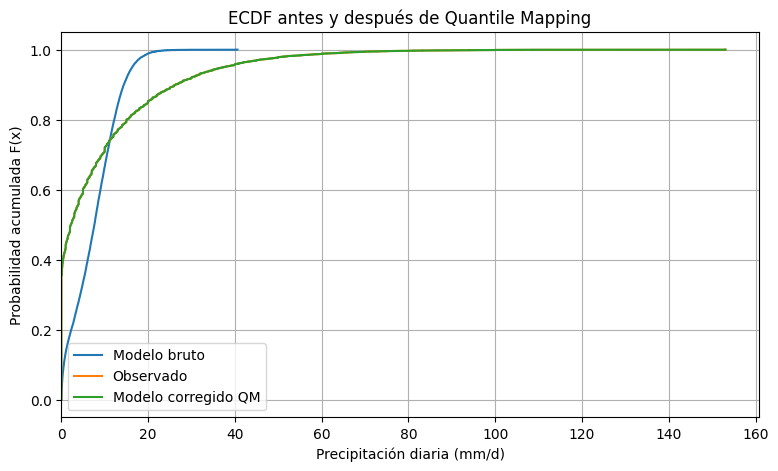

In [10]:
x_qm, p_qm = ecdf(cal["qm_mm"])

plt.figure()
plt.step(x_mod, p_mod, where="post", label="Modelo bruto")
plt.step(x_obs, p_obs, where="post", label="Observado")
plt.step(x_qm, p_qm, where="post", label="Modelo corregido QM")
plt.xlabel("Precipitación diaria (mm/d)")
plt.ylabel("Probabilidad acumulada F(x)")
plt.title("ECDF antes y después de Quantile Mapping")
plt.xlim(left=0)
plt.legend()
plt.show()

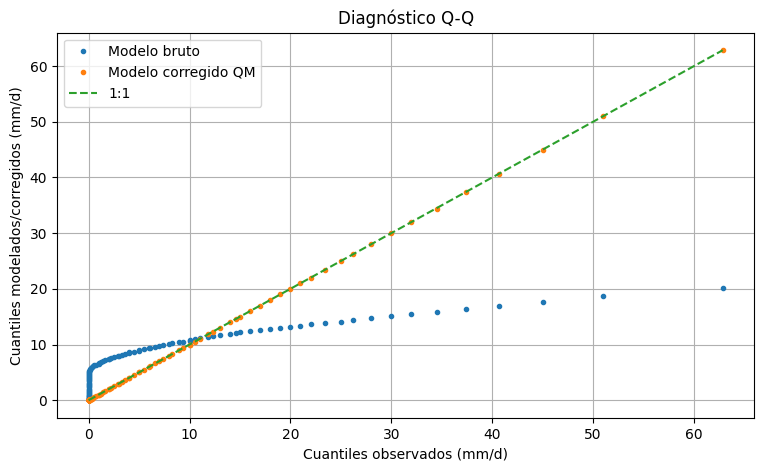

In [11]:
qplot = np.linspace(0.01, 0.99, 99)
q_obs = np.quantile(cal["obs_mm"], qplot)
q_mod = np.quantile(cal["modelo_mm"], qplot)
q_qm  = np.quantile(cal["qm_mm"], qplot)

plt.figure()
plt.plot(q_obs, q_mod, marker=".", linestyle="none", label="Modelo bruto")
plt.plot(q_obs, q_qm, marker=".", linestyle="none", label="Modelo corregido QM")
lim = max(q_obs.max(), q_mod.max(), q_qm.max())
plt.plot([0, lim], [0, lim], linestyle="--", label="1:1")
plt.xlabel("Cuantiles observados (mm/d)")
plt.ylabel("Cuantiles modelados/corregidos (mm/d)")
plt.title("Diagnóstico Q-Q")
plt.legend()
plt.show()

## 4.2 Aplicación de la función calibrada a la serie del modelo

La función mensual calibrada se aplica a toda la serie disponible. Para 1959–2014 representa el ajuste de referencia. Para 2015–2100 se muestra **solo como ejercicio computacional**, porque el archivo no informa qué escenario SSP corresponde a ese tramo.

Además, el QM clásico puede alterar la señal de cambio de los cuantiles futuros. Cannon et al. (2015) proponen **QDM** para preservar de manera explícita los cambios relativos de precipitación. Si el objetivo final es construir proyecciones de cambio climático para análisis hidrológico, se recomienda migrar este bloque a QDM después de confirmar el escenario del archivo.

In [12]:
modelo_qm = modelo[["fecha", "pr_mm_dia", "modelo"]].copy()

corr_todo, fuera_todo = apply_eqm_mensual(
    modelo_qm["fecha"],
    modelo_qm["pr_mm_dia"],
    params_qm
)

modelo_qm["pr_qm_mm_dia"] = corr_todo
modelo_qm["fuera_soporte_calibracion"] = fuera_todo
modelo_qm["periodo"] = np.where(
    modelo_qm["fecha"] <= CAL_END,
    "hasta_2014",
    "posterior_2014"
)

display(modelo_qm.head())
print("Casos fuera del soporte total:", int(modelo_qm["fuera_soporte_calibracion"].sum()))
print(
    "Casos fuera del soporte después de 2014:",
    int(modelo_qm.loc[modelo_qm["fecha"] > CAL_END, "fuera_soporte_calibracion"].sum())
)

,fecha,pr_mm_dia,modelo,pr_qm_mm_dia,fuera_soporte_calibracion,periodo
0,1950-01-01,0.609643,MPI-ESM1-2-HR,0.0,False,hasta_2014
1,1950-01-02,0.350828,MPI-ESM1-2-HR,0.0,False,hasta_2014
2,1950-01-03,0.102001,MPI-ESM1-2-HR,0.0,False,hasta_2014
3,1950-01-04,0.692246,MPI-ESM1-2-HR,0.0,False,hasta_2014
4,1950-01-05,4.974063,MPI-ESM1-2-HR,1.9,False,hasta_2014


Casos fuera del soporte total: 33
Casos fuera del soporte después de 2014: 32


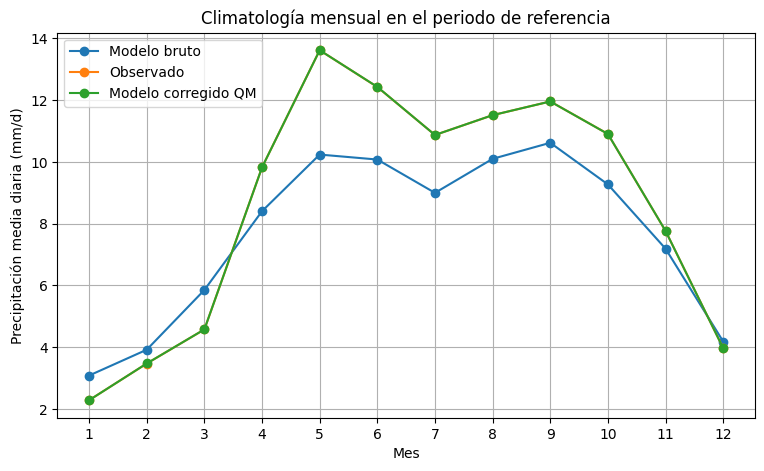

In [13]:
clim = cal.groupby("mes")[["modelo_mm", "obs_mm", "qm_mm"]].mean()

plt.figure()
plt.plot(clim.index, clim["modelo_mm"], marker="o", label="Modelo bruto")
plt.plot(clim.index, clim["obs_mm"], marker="o", label="Observado")
plt.plot(clim.index, clim["qm_mm"], marker="o", label="Modelo corregido QM")
plt.xlabel("Mes")
plt.ylabel("Precipitación media diaria (mm/d)")
plt.title("Climatología mensual en el periodo de referencia")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

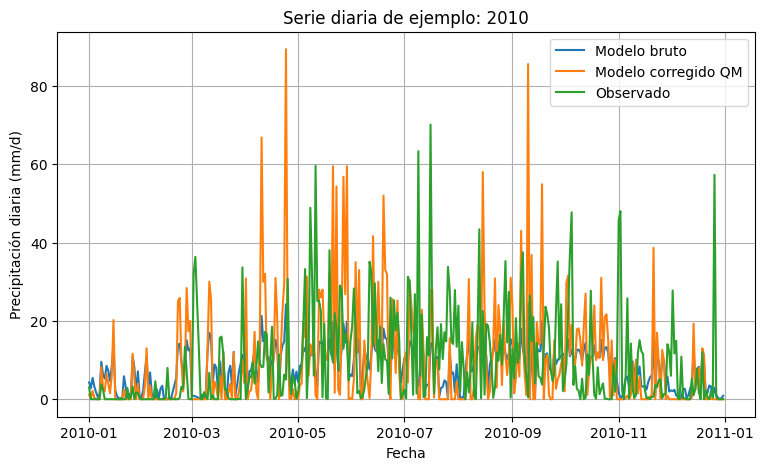

In [14]:
anio_demo = 2010
demo = cal.loc[cal["fecha"].dt.year == anio_demo].copy()

plt.figure()
plt.plot(demo["fecha"], demo["modelo_mm"], label="Modelo bruto")
plt.plot(demo["fecha"], demo["qm_mm"], label="Modelo corregido QM")
plt.plot(demo["fecha"], demo["obs_mm"], label="Observado")
plt.xlabel("Fecha")
plt.ylabel("Precipitación diaria (mm/d)")
plt.title(f"Serie diaria de ejemplo: {anio_demo}")
plt.legend()
plt.show()

In [15]:
salida_csv = Path("/content/precipitacion_QM_corregida.csv")
if not salida_csv.parent.exists():
    salida_csv = Path("precipitacion_QM_corregida.csv")

modelo_qm.to_csv(salida_csv, index=False)
print("Archivo de salida guardado en:", salida_csv)

Archivo de salida guardado en: precipitacion_QM_corregida.csv


# Respuestas sintéticas a las cuatro preguntas

### 1. ¿Qué es Quantile Mapping?

Es una transformación de ajuste de sesgo que relaciona cuantiles simulados y observados. Para un valor modelado \(x\), se calcula su probabilidad acumulada \(p=F_m(x)\) y se obtiene el valor observado correspondiente mediante \(F_o^{-1}(p)\):

\[
x_{\mathrm{QM}}=F_o^{-1}[F_m(x)].
\]

Por tanto, QM intenta que la **distribución marginal** del modelo corregido se parezca a la observada.

### 2. ¿Cómo se construyen las CDF?

Se parte de un periodo histórico común. Para cada serie se ordenan los valores y se calcula su frecuencia acumulada. La ECDF es:

\[
\widehat{F}_n(x)=\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}(x_i\le x).
\]

En precipitación se debe tratar explícitamente la masa en cero o el umbral de día húmedo. Después se construye una relación cuantil–cuantil entre modelo y observación.

### 3. ¿Cómo se aplica en hidrometeorología?

Se calibra una función de transferencia con observaciones y simulaciones históricas, y luego se aplica a una serie objetivo. Se utiliza para corregir sesgos en precipitación, temperatura y otras variables antes de estudios de impacto o modelación hidrológica. Debe validarse y documentarse el tratamiento de días secos, estacionalidad, extremos y extrapolación.

### 4. Ejemplo de downscaling de precipitación

Con los datos suministrados se ajustó un **EQM mensual** entre MPI-ESM1-2-HR y Carolina (27010500), utilizando 1959–2014 como referencia. El procedimiento:

1. iguala la frecuencia seco/húmedo;
2. construye cuantiles empíricos mensuales;
3. transforma la intensidad modelada al cuantil observado equivalente;
4. aplica la relación al resto de la serie.

Este ejercicio produce una serie cuyas distribuciones mensuales están ajustadas a la estación, pero **no reconstruye por sí solo la estructura espacial subgrid ni garantiza preservar la señal de cambio climático futura**.

# Limitaciones y recomendaciones para un uso operativo

1. **Verificar el escenario 2015–2100.** El archivo suministrado no indica SSP; no debe interpretarse la proyección hasta identificarlo.
2. **Separar calibración y validación.** El ajuste mostrado reproduce la distribución del periodo usado para calibrarlo; esto no constituye validación independiente.
3. **Revisar el umbral de día húmedo.** Se usó 0.1 mm/d como valor demostrativo; el umbral debe responder a la resolución y calidad del pluviómetro/base.
4. **Definir el tratamiento de colas.** Los valores fuera del soporte de calibración están marcados; para extremos se requiere una estrategia explícita de extrapolación.
5. **No confundir corrección marginal con downscaling espacial completo.** QM no agrega la variabilidad espacial/temporal no resuelta por el modelo.
6. **Para proyecciones de cambio climático, considerar QDM.** Cannon et al. (2015) muestran que QM clásico puede modificar tendencias de precipitación y extremos.
7. **Evaluar por estación y temporada.** El mapeo mensual usado aquí evita mezclar distribuciones estacionales, pero otras ventanas temporales pueden ser más apropiadas.

# Bibliografía

Cannon, A. J., Sobie, S. R., & Murdock, T. Q. (2015). Bias correction of GCM precipitation by quantile mapping: How well do methods preserve changes in quantiles and extremes? *Journal of Climate, 28*(17), 6938–6959. https://doi.org/10.1175/JCLI-D-14-00754.1

Eyring, V., Bony, S., Meehl, G. A., Senior, C. A., Stevens, B., Stouffer, R. J., & Taylor, K. E. (2016). Overview of the Coupled Model Intercomparison Project Phase 6 (CMIP6) experimental design and organization. *Geoscientific Model Development, 9*, 1937–1958. https://doi.org/10.5194/gmd-9-1937-2016

Gudmundsson, L., Bremnes, J. B., Haugen, J. E., & Engen-Skaugen, T. (2012). Technical Note: Downscaling RCM precipitation to the station scale using statistical transformations – a comparison of methods. *Hydrology and Earth System Sciences, 16*, 3383–3390. https://doi.org/10.5194/hess-16-3383-2012

Maraun, D. (2013). Bias correction, quantile mapping, and downscaling: Revisiting the inflation issue. *Journal of Climate, 26*(6), 2137–2143. https://doi.org/10.1175/JCLI-D-12-00821.1

Piani, C., Haerter, J. O., & Coppola, E. (2010). Statistical bias correction for daily precipitation in regional climate models over Europe. *Theoretical and Applied Climatology, 99*(1–2), 187–192. https://doi.org/10.1007/s00704-009-0134-9

Themeßl, M. J., Gobiet, A., & Leuprecht, A. (2011). Empirical-statistical downscaling and error correction of daily precipitation from regional climate models. *International Journal of Climatology, 31*(10), 1530–1544. https://doi.org/10.1002/joc.2168